In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

In [ ]:
#폰트 확인

for f in fm.fontManager.ttflist:
  name = f.name
  if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Apple', 'Batang', 'Gulim']):
      print(name)

MBatang
Showcard Gothic
Copperplate Gothic Bold
Malgun Gothic
Franklin Gothic Heavy
NanumGothic
Yu Gothic
Yu Gothic UI
Yu Gothic UI
Yu Gothic UI Semibold
Franklin Gothic Medium
Century Gothic
Franklin Gothic Demi Cond
Century Gothic
Franklin Gothic Medium Cond
Franklin Gothic Demi
Franklin Gothic Medium
NanumGothic
HCR Batang
New Gulim
HCR Batang ExtB
Copperplate Gothic Light
Franklin Gothic Demi
Yu Gothic
Yu Gothic Light
Yu Gothic UI
Yu Gothic UI Light
Franklin Gothic Book
Malgun Gothic
NanumGothic
NanumGothicExtraBold
HYGothic-Extra
Gulim
GulimChe
Batang
BatangChe
Franklin Gothic Book
Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
MJemokBatang
HCR Batang
Franklin Gothic Heavy
Malgun Gothic
Malgun Gothic Semilight
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
MJemokGothic
HCR Batang Ext
HYGothic-Medium
Century Gothic
Century Gothic
HCR Batang ExtB
MS Gothic
MS UI Gothic
MS PGothic


In [28]:
#나눔고딕 폰트로 그래프 폰트 변경(한글 깨짐 방지)
fm._load_fontmanager(try_read_cache=False)
plt.rc("font", family="NanumGothic")
plt.rc("axes", unicode_minus=False)

In [19]:
df = pd.read_csv('풍력.csv', encoding='cp949')
df

,시도명,설비용량(MW),발전일자,기온,강우량(mm),습도,적설량(mm),풍속,적운량(10분위),적운량(3분위),일조(hr),대기권밖일사량계산값,일사량,발전량(MWh),윤년여부
0,강원,295.334,2020-01-01 00:00,-3.0,NaN,24.0,NaN,4.3,0.0,1.0,NaN,0.0,NaN,0.01000,Y
1,강원,295.334,2020-01-01 01:00,-2.3,NaN,37.0,NaN,5.2,0.0,1.0,NaN,0.0,NaN,0.00000,Y
2,강원,295.334,2020-01-01 02:00,-1.6,NaN,38.0,NaN,3.9,0.0,1.0,NaN,0.0,NaN,0.00000,Y
3,강원,295.334,2020-01-01 03:00,-1.4,NaN,45.0,NaN,5.6,0.0,1.0,NaN,0.0,NaN,0.00000,Y
4,강원,295.334,2020-01-01 04:00,-0.9,NaN,46.0,NaN,5.1,0.0,1.0,NaN,0.0,NaN,0.00000,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806403,충북,416.000,2024-12-31 21:00,0.3,NaN,48.0,NaN,0.6,0.0,1.0,NaN,0.0,NaN,6.40000,Y
806404,충북,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45000,Y
806405,충북,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45081,Y
806406,충북,416.000,2024-12-31 23:00,-0.7,NaN,52.0,NaN,0.4,0.0,1.0,NaN,0.0,NaN,1.77408,Y


In [4]:
#상위 10개 데이터만 추출
sample_df = df.head(10)
sample_df

#샘플을 csv로 변환
sample_df.to_csv('sample_data.csv', index=False, encoding='cp949')

In [5]:
#결측치 유무 판단
df.isnull().sum()

시도명                0
설비용량(MW)           0
발전일자               0
기온               172
강우량(mm)       723553
습도               276
적설량(mm)       790155
풍속               903
적운량(10분위)        734
적운량(3분위)         734
일조(hr)        366427
대기권밖일사량계산값         0
일사량           366724
발전량(MWh)         527
윤년여부               0
dtype: int64

In [ ]:
#각 열에 대한 식별자를 판단
len(df) #전체 데이터의 갯수
df.nunique()   #unique 고유한 값의 갯수 파악 => 전체 데이터의 갯수와 비슷하다? = 식별자

#df.nunique() / len(df) 로 유일값 비율 계산 → 1에 가까우면 식별자.
unique_rate = df.nunique() / len(df)
print(unique_rate.sort_values(ascending=False))

발전량(MWh)      0.284491
발전일자          0.054017
설비용량(MW)      0.000853
기온            0.000696
대기권밖일사량계산값    0.000578
강우량(mm)       0.000553
일사량           0.000489
적설량(mm)       0.000382
풍속            0.000212
습도            0.000201
시도명           0.000021
적운량(10분위)     0.000014
일조(hr)        0.000014
적운량(3분위)      0.000004
윤년여부          0.000002
dtype: float64


In [10]:
#상식적으로 풍력발전량 예측에 필요없는 컬럼 지우기
#df.drop(columns='시도명', inplace=True)  #첫 번째 방식
sido_delete_df = df.drop(columns='시도명') #두 번째 방식(*추천)
sido_delete_df

,설비용량(MW),발전일자,기온,강우량(mm),습도,적설량(mm),풍속,적운량(10분위),적운량(3분위),일조(hr),대기권밖일사량계산값,일사량,발전량(MWh),윤년여부
0,295.334,2020-01-01 00:00,-3.0,NaN,24.0,NaN,4.3,0.0,1.0,NaN,0.0,NaN,0.01000,Y
1,295.334,2020-01-01 01:00,-2.3,NaN,37.0,NaN,5.2,0.0,1.0,NaN,0.0,NaN,0.00000,Y
2,295.334,2020-01-01 02:00,-1.6,NaN,38.0,NaN,3.9,0.0,1.0,NaN,0.0,NaN,0.00000,Y
3,295.334,2020-01-01 03:00,-1.4,NaN,45.0,NaN,5.6,0.0,1.0,NaN,0.0,NaN,0.00000,Y
4,295.334,2020-01-01 04:00,-0.9,NaN,46.0,NaN,5.1,0.0,1.0,NaN,0.0,NaN,0.00000,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806403,416.000,2024-12-31 21:00,0.3,NaN,48.0,NaN,0.6,0.0,1.0,NaN,0.0,NaN,6.40000,Y
806404,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45000,Y
806405,416.000,2024-12-31 22:00,-0.2,NaN,51.0,NaN,0.3,0.0,1.0,NaN,0.0,NaN,3.45081,Y
806406,416.000,2024-12-31 23:00,-0.7,NaN,52.0,NaN,0.4,0.0,1.0,NaN,0.0,NaN,1.77408,Y


In [20]:
#컬럼별 결측치 비율
#na_rate = sido_delete_df.isnull().sum() / len(sido_delete_df)
#na_rate

#강우량(mm), 적설량(mm), 일조(hr), 일사량, 윤년여부 컬럼 삭제
all_delete_df = df.drop(columns=['강우량(mm)', '적설량(mm)', '일조(hr)', '일사량', '윤년여부'])
all_delete_df

,시도명,설비용량(MW),발전일자,기온,습도,풍속,적운량(10분위),적운량(3분위),대기권밖일사량계산값,발전량(MWh)
0,강원,295.334,2020-01-01 00:00,-3.0,24.0,4.3,0.0,1.0,0.0,0.01000
1,강원,295.334,2020-01-01 01:00,-2.3,37.0,5.2,0.0,1.0,0.0,0.00000
2,강원,295.334,2020-01-01 02:00,-1.6,38.0,3.9,0.0,1.0,0.0,0.00000
3,강원,295.334,2020-01-01 03:00,-1.4,45.0,5.6,0.0,1.0,0.0,0.00000
4,강원,295.334,2020-01-01 04:00,-0.9,46.0,5.1,0.0,1.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...
806403,충북,416.000,2024-12-31 21:00,0.3,48.0,0.6,0.0,1.0,0.0,6.40000
806404,충북,416.000,2024-12-31 22:00,-0.2,51.0,0.3,0.0,1.0,0.0,3.45000
806405,충북,416.000,2024-12-31 22:00,-0.2,51.0,0.3,0.0,1.0,0.0,3.45081
806406,충북,416.000,2024-12-31 23:00,-0.7,52.0,0.4,0.0,1.0,0.0,1.77408


In [21]:
#시각화(차트)를 위한 라이브러리 설치
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.0 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.5 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 3.1 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 4.2 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.5 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.3 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 11.4 MB/s  0:00:00
   ---------------------------

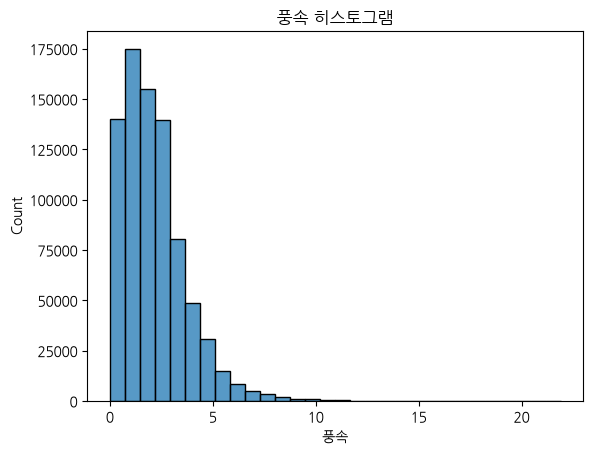

In [33]:
#히스토그램으로 풍속 데이터의 분포를 확인
sns.histplot(all_delete_df['풍속'], bins=30)
plt.title('풍속 히스토그램')
plt.show()

In [ ]:
#정규분포를 따르지 않기 때문에 이상치 판단은 IQR 방식
# 1Q(1 사분면 구함)
Q1 = all_delete_df['풍속'].quantile(0.25) #1.0
Q1

Q3 = all_delete_df['풍속'].quantile(0.75) #2.9
print(Q3)

IQR = Q3 - Q1
lower = Q1 - (1.5 * IQR) #-1.85
print(lower)
upper = Q3 + (1.5 * IQR) #5.75
print(upper)

2.9
-1.8499999999999996
5.75
